## Partie 2 : Segmentation Clients & Analyse de la Valeur Client (LTV)

> **Objectif** : Identifier les segments clients les plus rentables, modéliser les comportements d'achat et construire une segmentation actionnable pour guider les priorités de ciblage.

---
**Auteur** : Malcom Closse — Marketing Data Analyst  
**Prérequis** : Avoir exécuté la Partie 1 (fichier `data/processed/bank_clean.csv` requis)  
**Stack** : Python · Pandas · Matplotlib · Seaborn · Scikit-learn

---
## Import des librairies & configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
import os
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update(
    {
        "figure.dpi": 130,
        "axes.titlesize": 14,
        "axes.titleweight": "bold",
        "axes.titlepad": 14,
        "axes.labelsize": 11,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "figure.figsize": (12, 5),
    }
)

COLOR_YES = "#1D9E75"
COLOR_NO = "#D85A30"
COLOR_BASE = "#378ADD"
COLOR_GOLD = "#E8A820"
COLORS_DUAL = [COLOR_YES, COLOR_NO]

FIGURES_PATH = os.path.join("..", "outputs", "figures")
TABLES_PATH = os.path.join("..", "outputs", "tables")
os.makedirs(FIGURES_PATH, exist_ok=True)
os.makedirs(TABLES_PATH, exist_ok=True)

print("✅ Librairies chargées avec succès")

✅ Librairies chargées avec succès


---
## Chargement des données nettoyées (Partie 1)

In [2]:
PROCESSED_PATH = os.path.join("..", "data", "processed", "bank_clean.csv")

df = pd.read_csv(PROCESSED_PATH)

# Restaurer l'ordre calendaire des mois
MONTH_ORDER = [
    "jan",
    "feb",
    "mar",
    "apr",
    "may",
    "jun",
    "jul",
    "aug",
    "sep",
    "oct",
    "nov",
    "dec",
]
df["month"] = pd.Categorical(df["month"], categories=MONTH_ORDER, ordered=True)

print(f"✅ Dataset chargé : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")
print(f"   Taux de conversion global : {df['subscribed_bin'].mean() * 100:.1f}%")
df.head(3)

✅ Dataset chargé : 11,162 lignes × 19 colonnes
   Taux de conversion global : 47.4%


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,subscribed,subscribed_bin,never_contacted
0,59,admin.,married,secondary,no,2343,yes,no,NaN,5,may,1042,1,NaN,0,NaN,yes,1,1
1,56,admin.,married,secondary,no,45,no,no,NaN,5,may,1467,1,NaN,0,NaN,yes,1,1
2,41,technician,married,secondary,no,1270,yes,no,NaN,5,may,1389,1,NaN,0,NaN,yes,1,1


---
## Analyse de la valeur financière client (Proxy LTV)

> Dans ce dataset, la LTV est approximée par le **solde bancaire annuel moyen** (`balance`). Un solde élevé = client à fort potentiel patrimonial.

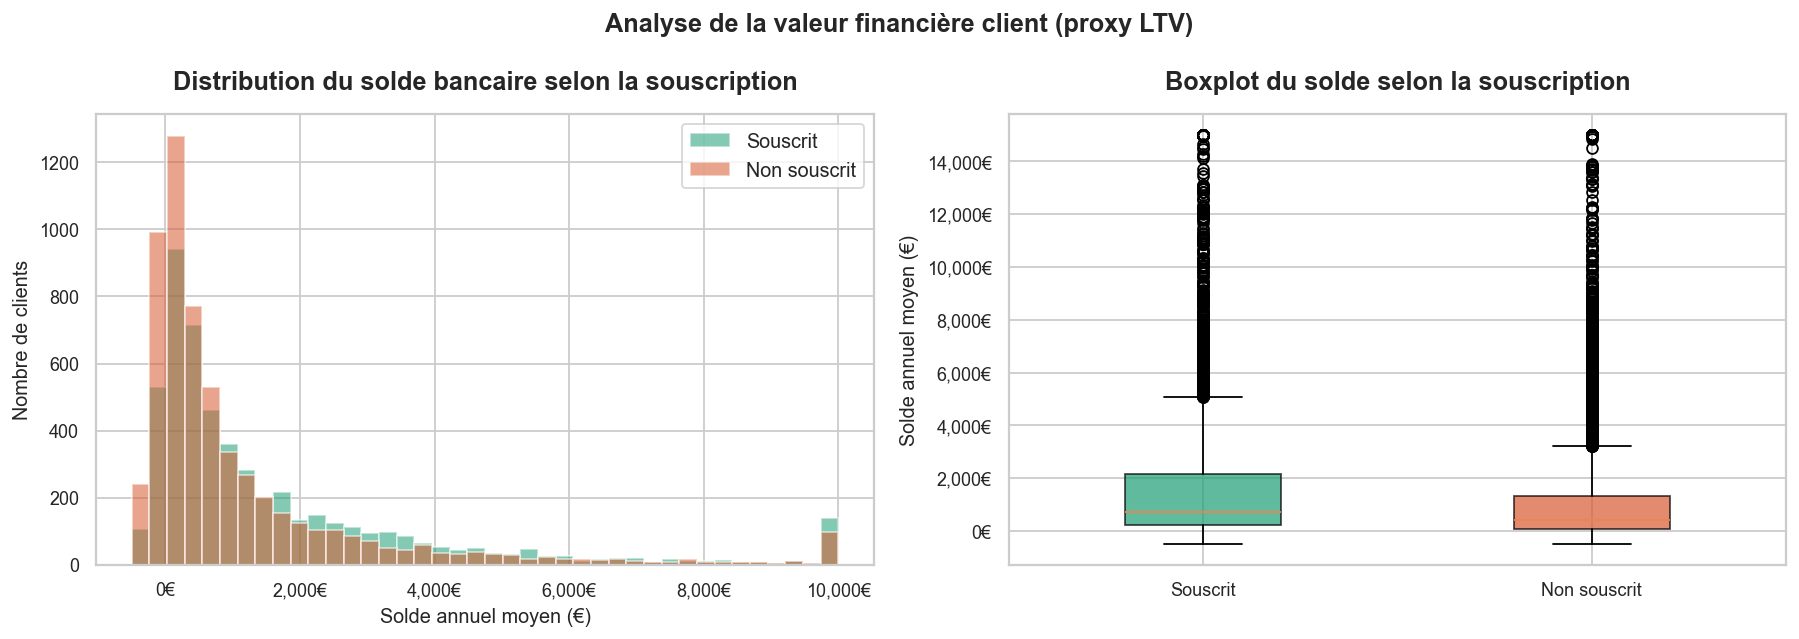

Solde moyen — Souscrit     : 1,804 €
Solde moyen — Non souscrit : 1,280 €


In [3]:
# --- Distribution du solde bancaire ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogramme par statut de souscription
for val, color, label in [
    ("yes", COLOR_YES, "Souscrit"),
    ("no", COLOR_NO, "Non souscrit"),
]:
    subset = df[df["subscribed"] == val]["balance"].clip(-500, 10000)
    axes[0].hist(
        subset, bins=40, alpha=0.55, color=color, label=label, edgecolor="white"
    )
axes[0].set_title("Distribution du solde bancaire selon la souscription")
axes[0].set_xlabel("Solde annuel moyen (€)")
axes[0].set_ylabel("Nombre de clients")
axes[0].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{int(x):,}€"))
axes[0].legend()

# Boxplot
bp_data = [
    df[df["subscribed"] == "yes"]["balance"].clip(-500, 15000),
    df[df["subscribed"] == "no"]["balance"].clip(-500, 15000),
]
bp = axes[1].boxplot(
    bp_data, patch_artist=True, labels=["Souscrit", "Non souscrit"], widths=0.4
)
for patch, color in zip(bp["boxes"], COLORS_DUAL):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_title("Boxplot du solde selon la souscription")
axes[1].set_ylabel("Solde annuel moyen (€)")
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda y, _: f"{int(y):,}€"))

plt.suptitle(
    "Analyse de la valeur financière client (proxy LTV)", fontsize=14, fontweight="bold"
)
plt.tight_layout()
plt.savefig(
    os.path.join(FIGURES_PATH, "10_balance_vs_conversion.png"),
    dpi=150,
    bbox_inches="tight",
)
plt.show()

print(
    f"Solde moyen — Souscrit     : {df[df['subscribed'] == 'yes']['balance'].mean():,.0f} €"
)
print(
    f"Solde moyen — Non souscrit : {df[df['subscribed'] == 'no']['balance'].mean():,.0f} €"
)

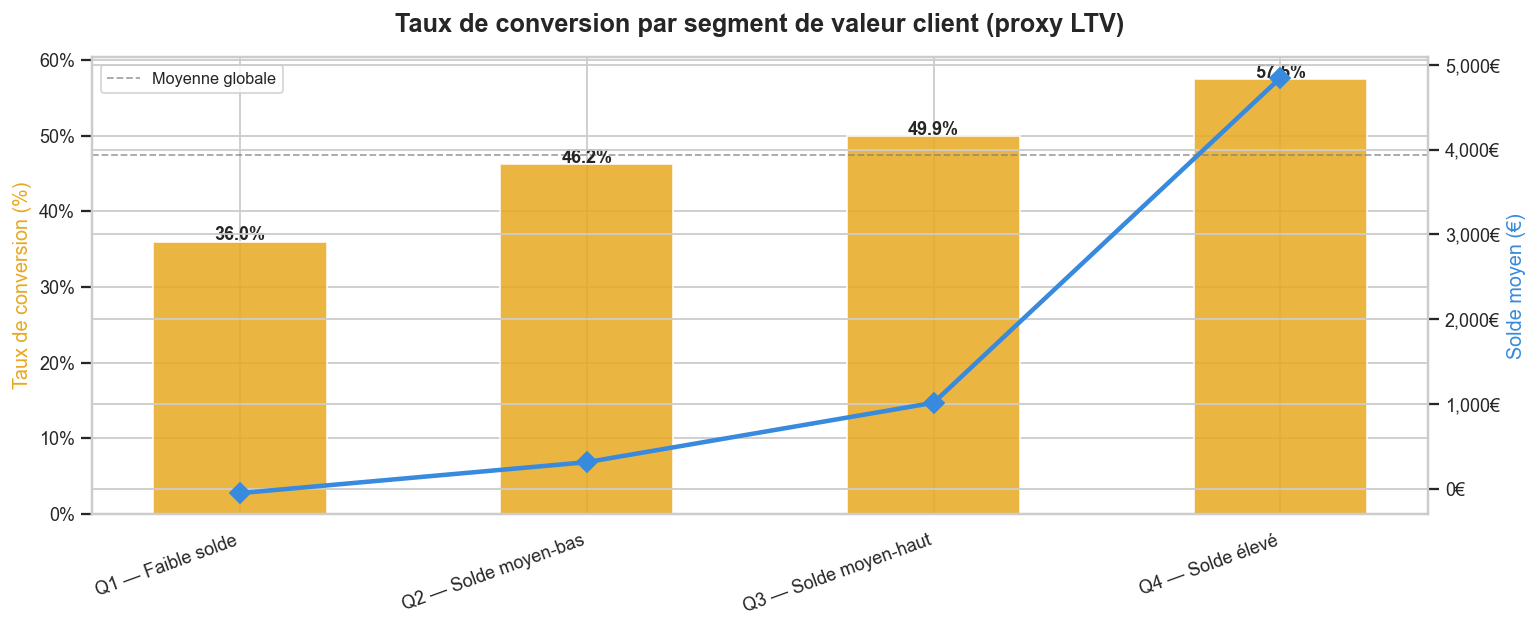


 Détail par segment LTV :


,nb_clients,taux_conversion,solde_moyen,solde_median
balance_segment,,,,
Q1 — Faible solde,2792,35.96,-54.30,0.0
Q2 — Solde moyen-bas,2791,46.22,311.11,300.0
Q3 — Solde moyen-haut,2789,49.87,1012.10,952.0
Q4 — Solde élevé,2790,57.49,4846.63,3343.0


 Tableau exporté → outputs/tables/ltv_segments.csv


In [5]:
# --- Segmentation LTV par quartile de solde ---
df["balance_segment"] = pd.qcut(
    df["balance"],
    q=4,
    labels=[
        "Q1 — Faible solde",
        "Q2 — Solde moyen-bas",
        "Q3 — Solde moyen-haut",
        "Q4 — Solde élevé",
    ],
)

grp_balance = (
    df.groupby("balance_segment", observed=True)
    .agg(
        nb_clients=("subscribed_bin", "count"),
        taux_conversion=("subscribed_bin", "mean"),
        solde_moyen=("balance", "mean"),
        solde_median=("balance", "median"),
    )
    .assign(taux_conversion=lambda x: x["taux_conversion"] * 100)
    .round(2)
)

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

x = range(len(grp_balance))
bars = ax1.bar(
    x,
    grp_balance["taux_conversion"],
    color=COLOR_GOLD,
    alpha=0.85,
    edgecolor="white",
    width=0.5,
)
ax2.plot(
    x,
    grp_balance["solde_moyen"],
    color=COLOR_BASE,
    marker="D",
    linewidth=2.5,
    markersize=8,
)

for bar, val in zip(bars, grp_balance["taux_conversion"]):
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.2,
        f"{val:.1f}%",
        ha="center",
        fontsize=10,
        fontweight="bold",
    )

ax1.set_xticks(list(x))
ax1.set_xticklabels(grp_balance.index, rotation=20, ha="right")
ax1.set_ylabel("Taux de conversion (%)", color=COLOR_GOLD)
ax1.yaxis.set_major_formatter(mtick.FuncFormatter(lambda y, _: f"{y:.0f}%"))
ax2.set_ylabel("Solde moyen (€)", color=COLOR_BASE)
ax2.yaxis.set_major_formatter(mtick.FuncFormatter(lambda y, _: f"{int(y):,}€"))
ax1.axhline(
    df["subscribed_bin"].mean() * 100,
    color="gray",
    linestyle="--",
    linewidth=1,
    alpha=0.7,
    label="Moyenne globale",
)
ax1.set_title("Taux de conversion par segment de valeur client (proxy LTV)")
ax1.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.savefig(
    os.path.join(FIGURES_PATH, "11_ltv_segments.png"), dpi=150, bbox_inches="tight"
)
plt.show()

print("\n Détail par segment LTV :")
display(grp_balance)
grp_balance.to_csv(os.path.join(TABLES_PATH, "ltv_segments.csv"))
print(" Tableau exporté → outputs/tables/ltv_segments.csv")

---
## Segmentation par profil socio-démographique croisé

> Construire le **profil idéal** du client qui souscrit en croisant job × education × marital.

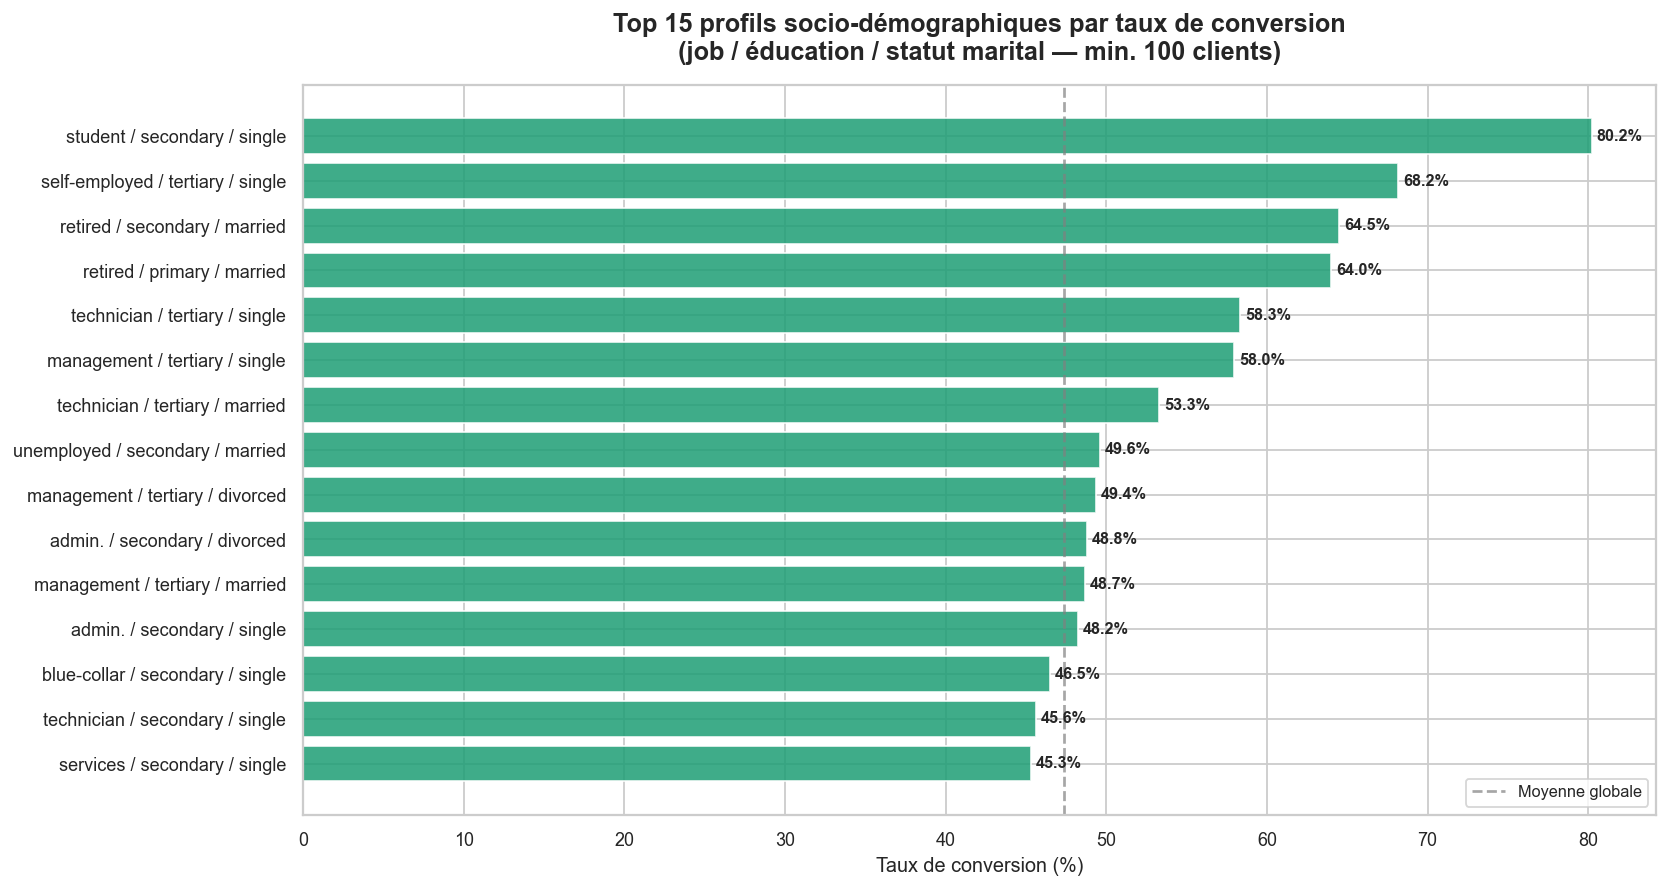


 Top 5 profils à cibler en priorité :


,profil,nb_clients,taux_conversion,solde_moyen
0,student / secondary / single,182,80.22,1344.38
1,self-employed / tertiary / single,110,68.18,1940.65
2,retired / secondary / married,245,64.49,3085.23
3,retired / primary / married,200,64.00,2254.44
4,technician / tertiary / single,252,58.33,1957.38


 Tableau exporté → outputs/tables/top_profils.csv


In [8]:
# --- Top 15 profils combinés ---
profils = (
    df.groupby(["job", "education", "marital"])
    .agg(
        nb_clients=("subscribed_bin", "count"),
        taux_conversion=("subscribed_bin", "mean"),
        solde_moyen=("balance", "mean"),
    )
    .assign(taux_conversion=lambda x: x["taux_conversion"] * 100)
    .query("nb_clients >= 100")
    .sort_values("taux_conversion", ascending=False)
    .round(2)
    .head(15)
    .reset_index()
)

profils["profil"] = (
    profils["job"] + " / " + profils["education"] + " / " + profils["marital"]
)

fig, ax = plt.subplots(figsize=(13, 7))
bars = ax.barh(
    profils["profil"][::-1],
    profils["taux_conversion"][::-1],
    color=COLOR_YES,
    alpha=0.85,
    edgecolor="white",
)
for bar, val in zip(bars, profils["taux_conversion"][::-1]):
    ax.text(
        val + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.1f}%",
        va="center",
        fontsize=9,
        fontweight="bold",
    )
ax.axvline(
    df["subscribed_bin"].mean() * 100,
    color="gray",
    linestyle="--",
    linewidth=1.5,
    alpha=0.7,
    label="Moyenne globale",
)
ax.set_xlabel("Taux de conversion (%)")
ax.set_title(
    "Top 15 profils socio-démographiques par taux de conversion\n(job / éducation / statut marital — min. 100 clients)"
)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(
    os.path.join(FIGURES_PATH, "12_top_profils.png"), dpi=150, bbox_inches="tight"
)
plt.show()

print("\n Top 5 profils à cibler en priorité :")
display(profils[["profil", "nb_clients", "taux_conversion", "solde_moyen"]].head(5))
profils.to_csv(os.path.join(TABLES_PATH, "top_profils.csv"), index=False)
print(" Tableau exporté → outputs/tables/top_profils.csv")

---
## Heatmap de conversion — Job × Mois

> Quelle combinaison job + mois maximise les chances de conversion ?

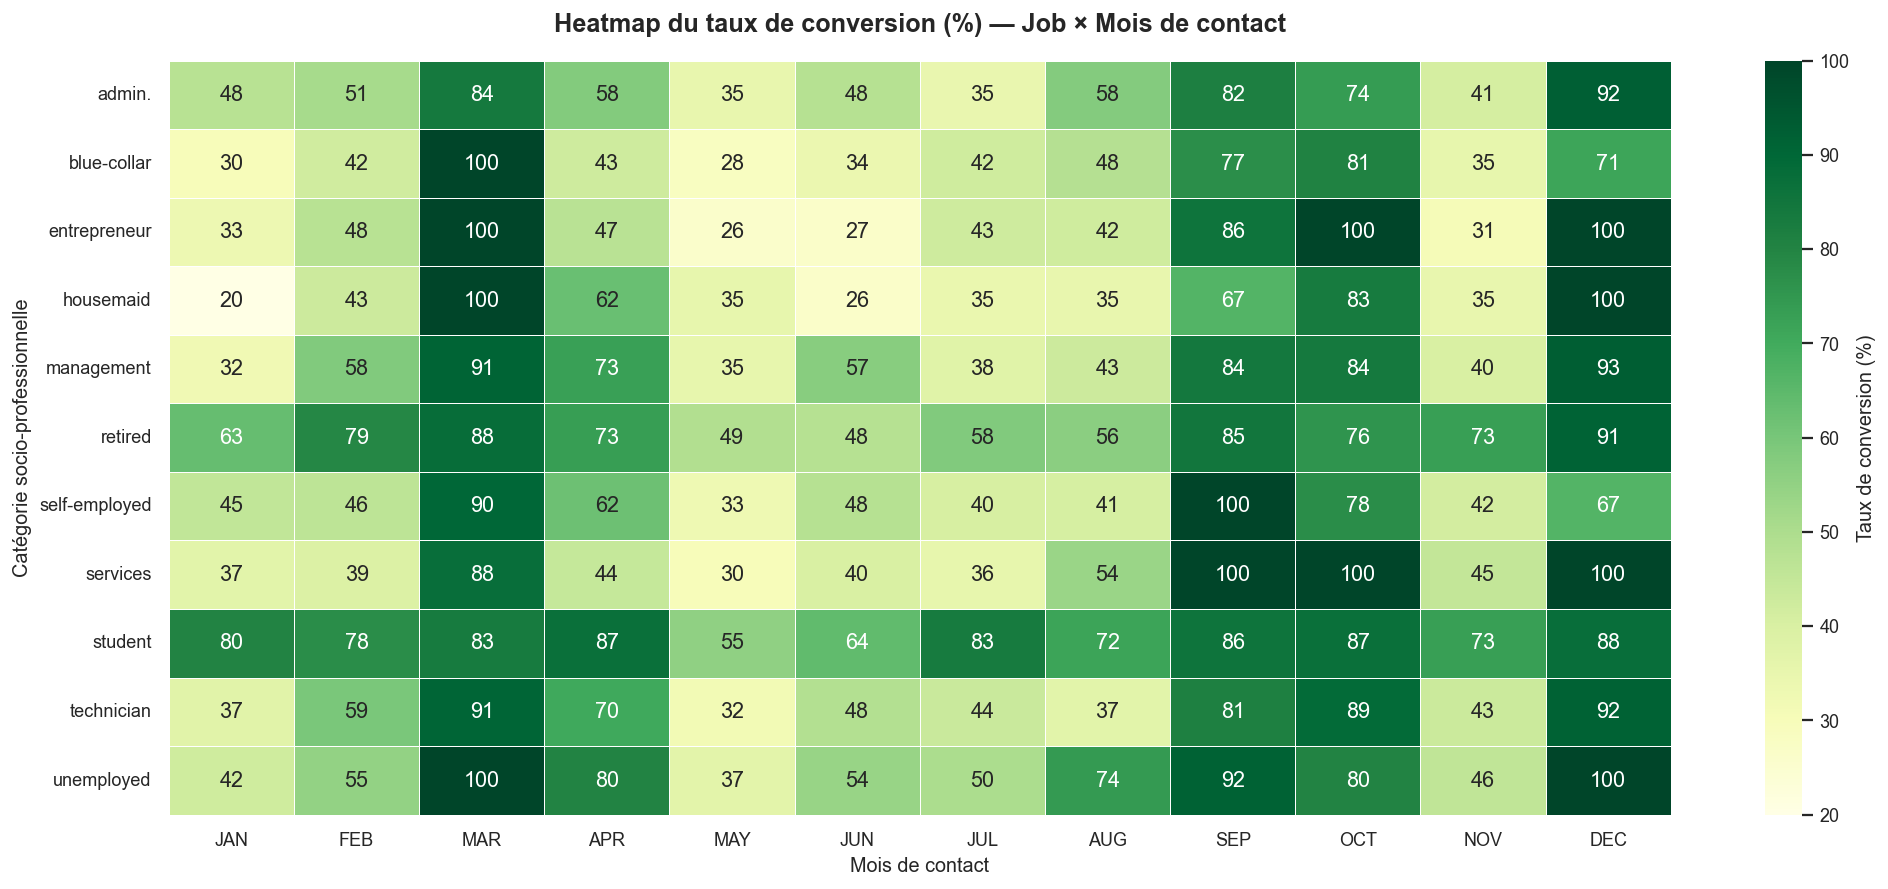

Les cases les plus foncées = combinaisons job × mois à prioriser dans la campagne


In [10]:
pivot_job_month = (
    df.groupby(["job", "month"], observed=True)["subscribed_bin"]
    .mean()
    .unstack("month")
    * 100
)

# Réordonner les mois
pivot_job_month = pivot_job_month.reindex(
    columns=[m for m in MONTH_ORDER if m in pivot_job_month.columns]
)

fig, ax = plt.subplots(figsize=(16, 7))
sns.heatmap(
    pivot_job_month,
    annot=True,
    fmt=".0f",
    cmap="YlGn",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Taux de conversion (%)"},
    ax=ax,
)
ax.set_title("Heatmap du taux de conversion (%) — Job × Mois de contact", pad=16)
ax.set_xlabel("Mois de contact")
ax.set_ylabel("Catégorie socio-professionnelle")
ax.set_xticklabels([m.upper() for m in pivot_job_month.columns], rotation=0)
plt.tight_layout()
plt.savefig(
    os.path.join(FIGURES_PATH, "13_heatmap_job_mois.png"), dpi=150, bbox_inches="tight"
)
plt.show()

print(
    "Les cases les plus foncées = combinaisons job × mois à prioriser dans la campagne"
)

---
## Impact des prêts sur la conversion

> Un client avec un prêt immobilier ou personnel est-il moins susceptible de souscrire ?

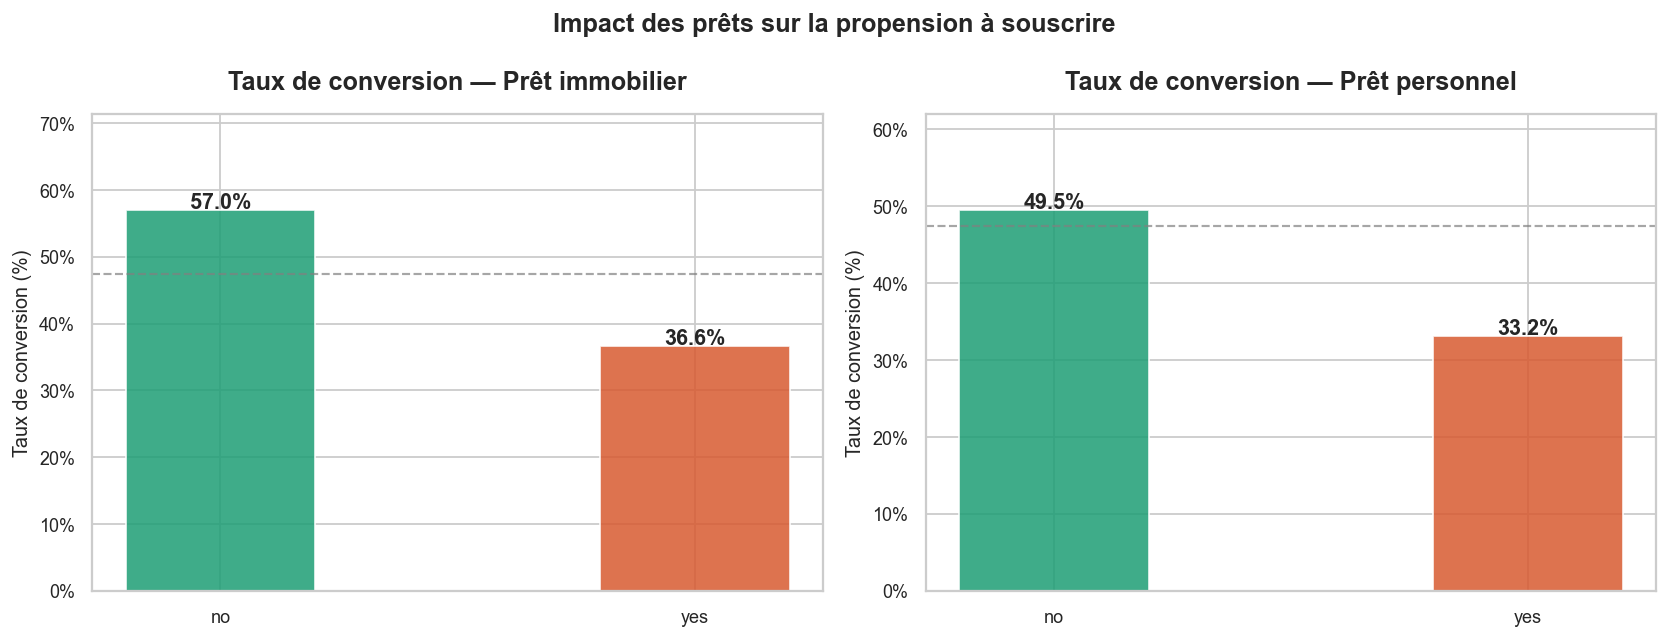

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, col, title in [
    (axes[0], "housing", "Prêt immobilier"),
    (axes[1], "loan", "Prêt personnel"),
]:
    grp = df.groupby(col)["subscribed_bin"].mean() * 100
    colors = [COLOR_YES if v == grp.max() else COLOR_NO for v in grp.values]
    bars = ax.bar(
        grp.index, grp.values, color=colors, alpha=0.85, edgecolor="white", width=0.4
    )
    for bar, val in zip(bars, grp.values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.2,
            f"{val:.1f}%",
            ha="center",
            fontweight="bold",
            fontsize=12,
        )
    ax.axhline(
        df["subscribed_bin"].mean() * 100,
        color="gray",
        linestyle="--",
        linewidth=1.2,
        alpha=0.7,
    )
    ax.set_title(f"Taux de conversion — {title}")
    ax.set_ylabel("Taux de conversion (%)")
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda y, _: f"{y:.0f}%"))
    ax.set_ylim(0, grp.max() * 1.25)

plt.suptitle(
    "Impact des prêts sur la propension à souscrire", fontsize=14, fontweight="bold"
)
plt.tight_layout()
plt.savefig(
    os.path.join(FIGURES_PATH, "14_impact_prets.png"), dpi=150, bbox_inches="tight"
)
plt.show()

---
## Matrice de corrélation des variables numériques

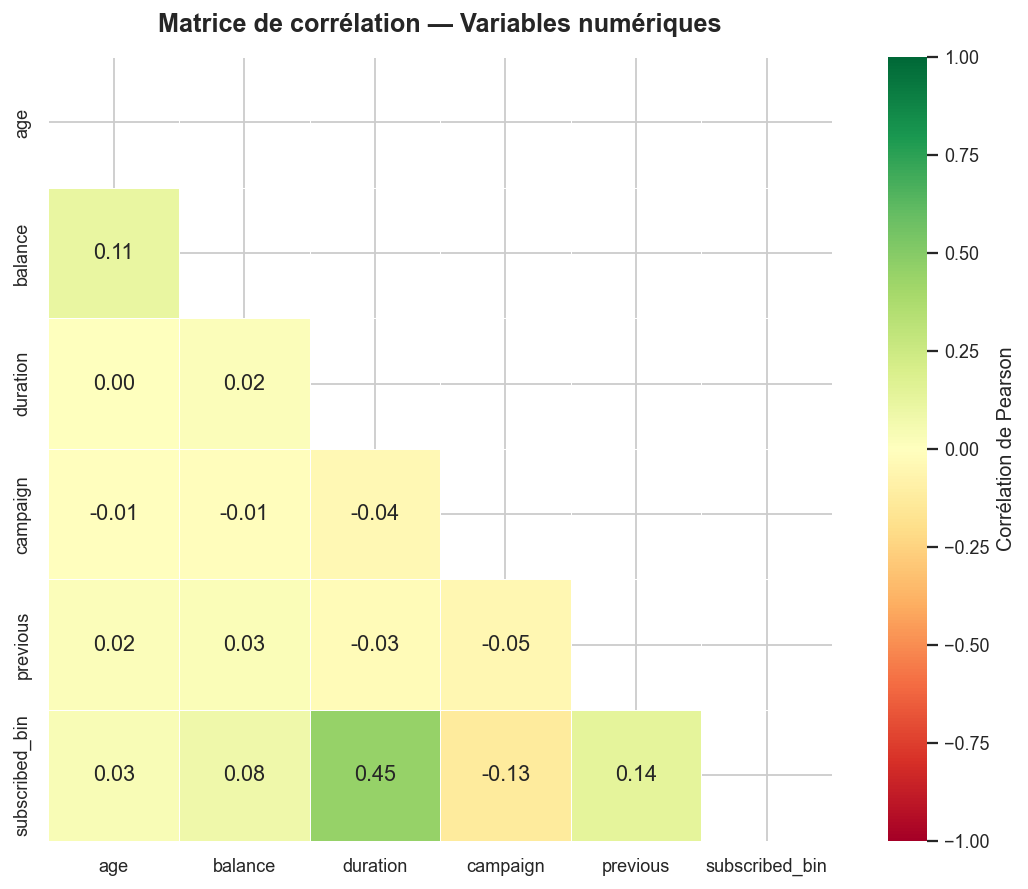


 Variables les plus corrélées avec la souscription :
duration    0.451919
previous    0.139867
balance     0.081129
age         0.034901
campaign   -0.128081


In [12]:
num_cols = ["age", "balance", "duration", "campaign", "previous", "subscribed_bin"]

corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    linecolor="white",
    square=True,
    ax=ax,
    cbar_kws={"label": "Corrélation de Pearson"},
)
ax.set_title("Matrice de corrélation — Variables numériques", pad=14)
plt.tight_layout()
plt.savefig(
    os.path.join(FIGURES_PATH, "15_correlation_matrix.png"),
    dpi=150,
    bbox_inches="tight",
)
plt.show()

print("\n Variables les plus corrélées avec la souscription :")
print(
    corr["subscribed_bin"]
    .drop("subscribed_bin")
    .sort_values(ascending=False)
    .to_string()
)

---
## Construction de la segmentation finale — 3 segments actionnables

> Traduire l'analyse en **segments marketing opérationnels** : Chaud / Tiède / Froid

In [13]:
def assign_segment(row):
    """
    Règles de segmentation basées sur les insights des parties 1 & 2.
    Segment CHAUD  : fort potentiel de conversion.
    Segment TIÈDE  : potentiel modéré, à qualifier.
    Segment FROID  : faible potentiel, coût à minimiser.
    """
    score = 0

    # Job à fort taux historique
    if row.get("job") in ["retired", "student", "management", "admin."]:
        score += 2

    # Pas de prêt immobilier
    if row.get("housing") == "no":
        score += 1

    # Pas de prêt personnel
    if row.get("loan") == "no":
        score += 1

    # Solde élevé (Q3 ou Q4)
    if row.get("balance", 0) > 500:
        score += 1

    # Ancien souscripteur (campagne précédente réussie)
    if row.get("poutcome") == "success":
        score += 3

    # Peu de contacts cette campagne (pas encore saturé)
    if row.get("campaign", 99) <= 3:
        score += 1

    # Défaut de crédit
    if row.get("default") == "yes":
        score -= 2

    # Classification
    if score >= 5:
        return "CHAUD"
    elif score >= 2:
        return "TIÈDE"
    else:
        return "FROID"


df["segment"] = df.apply(assign_segment, axis=1)

print("Segmentation appliquée")
print("\nRépartition des segments :")
print(df["segment"].value_counts())

Segmentation appliquée

Répartition des segments :
segment
TIÈDE    6502
CHAUD    3907
FROID     753
Name: count, dtype: int64


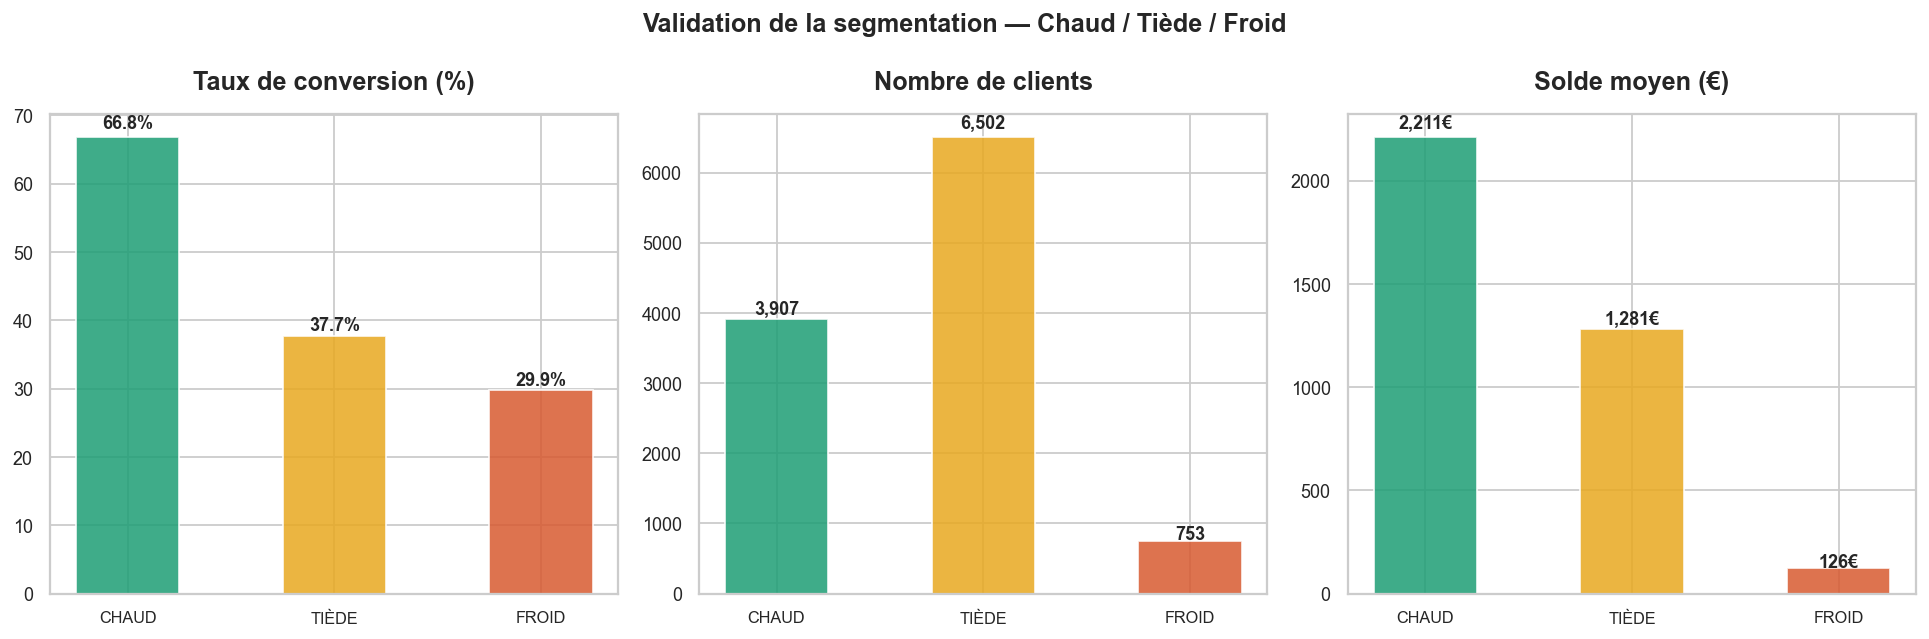


 Tableau de validation :


,nb_clients,taux_conversion,solde_moyen,nb_contacts_moy
segment,,,,
CHAUD,3907,66.80,2210.93,1.93
TIÈDE,6502,37.74,1280.90,2.60
FROID,753,29.88,126.14,4.78


Tableau exporté → outputs/tables/segmentation_validation.csv


In [14]:
# --- Validation de la segmentation ---
validation = (
    df.groupby("segment")
    .agg(
        nb_clients=("subscribed_bin", "count"),
        taux_conversion=("subscribed_bin", "mean"),
        solde_moyen=("balance", "mean"),
        nb_contacts_moy=("campaign", "mean"),
    )
    .assign(taux_conversion=lambda x: x["taux_conversion"] * 100)
    .round(2)
)

# --- Visualisation ---
seg_order = ["CHAUD", "TIÈDE", "FROID"]
seg_colors = [COLOR_YES, COLOR_GOLD, COLOR_NO]
validation = validation.reindex([s for s in seg_order if s in validation.index])

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics = [
    ("taux_conversion", "Taux de conversion (%)", "{:.1f}%"),
    ("nb_clients", "Nombre de clients", "{:,.0f}"),
    ("solde_moyen", "Solde moyen (€)", "{:,.0f}€"),
]

for ax, (metric, ylabel, fmt) in zip(axes, metrics):
    bars = ax.bar(
        validation.index,
        validation[metric],
        color=seg_colors[: len(validation)],
        alpha=0.85,
        edgecolor="white",
        width=0.5,
    )
    for bar, val in zip(bars, validation[metric]):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() * 1.02,
            fmt.format(val),
            ha="center",
            fontsize=10,
            fontweight="bold",
        )
    ax.set_title(ylabel)
    ax.set_xticklabels(validation.index, fontsize=9)

plt.suptitle(
    "Validation de la segmentation — Chaud / Tiède / Froid",
    fontsize=14,
    fontweight="bold",
)
plt.tight_layout()
plt.savefig(
    os.path.join(FIGURES_PATH, "16_validation_segments.png"),
    dpi=150,
    bbox_inches="tight",
)
plt.show()

print("\n Tableau de validation :")
display(validation)
validation.to_csv(os.path.join(TABLES_PATH, "segmentation_validation.csv"))
print("Tableau exporté → outputs/tables/segmentation_validation.csv")

In [ ]:
# --- Répartition des segments (donut) ---
seg_counts = (
    df["segment"]
    .value_counts()
    .reindex([s for s in seg_order if s in df["segment"].unique()])
)

fig, ax = plt.subplots(figsize=(8, 6))
wedges, texts, autotexts = ax.pie(
    seg_counts.values,
    labels=seg_counts.index,
    colors=seg_colors[: len(seg_counts)],
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops=dict(width=0.55, edgecolor="white", linewidth=2),
)
for text in texts:
    text.set_fontsize(11)
    text.set_fontweight("bold")
for autotext in autotexts:
    autotext.set_fontsize(10)
ax.set_title(
    "Répartition des clients par segment marketing", fontsize=14, fontweight="bold"
)
plt.tight_layout()
plt.savefig(
    os.path.join(FIGURES_PATH, "17_repartition_segments.png"),
    dpi=150,
    bbox_inches="tight",
)
plt.show()

---
## Analyse de la durée d'appel selon le segment

> La durée de l'appel est le signal le plus corrélé à la conversion. Comment varie-t-elle par segment ?

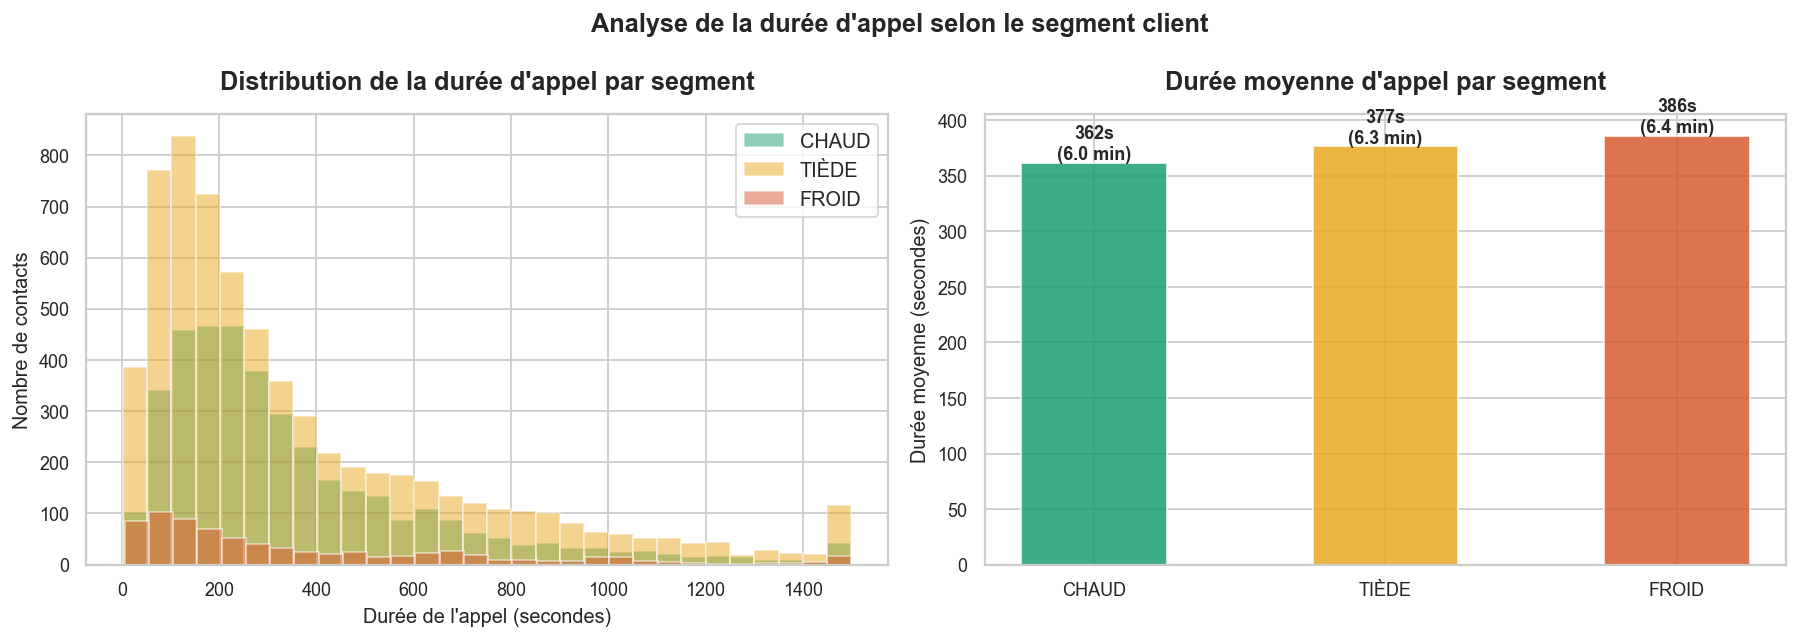

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution de la durée par segment
for seg, color in zip(seg_order, seg_colors):
    if seg in df["segment"].unique():
        subset = df[df["segment"] == seg]["duration"].clip(0, 1500)
        axes[0].hist(
            subset, bins=30, alpha=0.5, color=color, label=seg, edgecolor="white"
        )
axes[0].set_title("Distribution de la durée d'appel par segment")
axes[0].set_xlabel("Durée de l'appel (secondes)")
axes[0].set_ylabel("Nombre de contacts")
axes[0].legend()

# Durée moyenne par segment
dur_seg = (
    df.groupby("segment")["duration"]
    .mean()
    .reindex([s for s in seg_order if s in df["segment"].unique()])
)
bars = axes[1].bar(
    dur_seg.index,
    dur_seg.values,
    color=seg_colors[: len(dur_seg)],
    alpha=0.85,
    edgecolor="white",
    width=0.5,
)
for bar, val in zip(bars, dur_seg.values):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 3,
        f"{val:.0f}s\n({val / 60:.1f} min)",
        ha="center",
        fontsize=10,
        fontweight="bold",
    )
axes[1].set_title("Durée moyenne d'appel par segment")
axes[1].set_ylabel("Durée moyenne (secondes)")

plt.suptitle(
    "Analyse de la durée d'appel selon le segment client",
    fontsize=14,
    fontweight="bold",
)
plt.tight_layout()
plt.savefig(
    os.path.join(FIGURES_PATH, "18_duree_appel_segments.png"),
    dpi=150,
    bbox_inches="tight",
)
plt.show()

---
## Export final & synthèse

> Sauvegarde du dataset enrichi avec les segments pour la Partie 3 (Scoring).

In [16]:
# --- Export du dataset segmenté ---
segmented_path = os.path.join("..", "data", "processed", "bank_segmented.csv")
df.to_csv(segmented_path, index=False)
print(f"Dataset segmenté sauvegardé → {segmented_path}")
print(f"   Colonnes ajoutées : balance_segment, segment")

# --- Synthèse finale ---
print("\n" + "=" * 58)
print("   SYNTHÈSE INSIGHTS — PARTIE 2")
print("=" * 58)

top_profil = profils.iloc[0]
chaud = validation.loc["CHAUD"] if "CHAUD" in validation.index else None

insights = [
    (
        "Solde moyen — clients convertis",
        f"{df[df['subscribed'] == 'yes']['balance'].mean():,.0f} € vs "
        f"{df[df['subscribed'] == 'no']['balance'].mean():,.0f} € (non convertis)",
    ),
    (
        "Profil socio-démographique idéal",
        f"{top_profil['profil']} ({top_profil['taux_conversion']:.1f}%)",
    ),
    (
        "Taux de conversion — Segment CHAUD",
        f"{chaud['taux_conversion']:.1f}%" if chaud is not None else "N/A",
    ),
    ("Variable la + corrélée à la conversion", "Durée de l'appel (duration)"),
    (
        "Impact prêt immobilier",
        "Clients sans prêt immobilier convertissent significativement plus",
    ),
    ("Action prioritaire", "Cibler le segment CHAUD en priorité → ROI maximal"),
]

for label, value in insights:
    print(f"   {label}")
    print(f"   → {value}")
    print()

print("=" * 58)
print("\n➡️  Prochaine étape : Partie 3 — Scoring de propension & recommandations")

Dataset segmenté sauvegardé → ../data/processed/bank_segmented.csv
   Colonnes ajoutées : balance_segment, segment

   SYNTHÈSE INSIGHTS — PARTIE 2
   Solde moyen — clients convertis
   → 1,804 € vs 1,280 € (non convertis)

   Profil socio-démographique idéal
   → student / secondary / single (80.2%)

   Taux de conversion — Segment CHAUD
   → 66.8%

   Variable la + corrélée à la conversion
   → Durée de l'appel (duration)

   Impact prêt immobilier
   → Clients sans prêt immobilier convertissent significativement plus

   Action prioritaire
   → Cibler le segment CHAUD en priorité → ROI maximal


➡️  Prochaine étape : Partie 3 — Scoring de propension & recommandations
